In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

# Exercise 06



## Exercise 06.1
### Assignment

Complete the NSL_simulator code to simulate a 1D Ising model with the Gibbs sampling algorithm (the Metropolis algorithm is already implemented) to sample the Boltzmann's weight $p(\{ s_i \}) = \exp(-\beta H)/Z$. Verify the possibility to restart from a previous spin configuration.

The code already computes the internal energy: $U(N,T) = \langle H \rangle$. Add the calculation of $C(N,T)$, $\chi(N,T)$, $M(N,T,h)$ and compute:
1. $U(N,T) = \langle H \rangle_{h=0}$
2. $C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$ 
3. $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$
4. $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$

as a function of $T$ in the range $\left[0.5;2.0\right]$ for a system of $N=50$ spins with $J=1$.

As usual, use data blocking and give an estimate of the statistical uncertainties.

- Show pictures of your estimations of ${U(N,T), C(N,T), \chi(N,T), M(N,T,h=0.02)}$  and their uncertainties</span> obtained with a large number of *MC steps* (e.g. $M\ge 10^5$) compared with the exact curves. In the same picture show your results obtained with both sampling methods, Metropolis and Gibbs</span>.

A Monte Carlo step will consist in trying to flip one time all the spins of the system. Do not forget to equilibrate your simulations and to use blocking average with blocks large enough.

### Solution

First, I inspected the equilibration time needed for Gibbs and Metropolis, with different initial temperatures. To do so, executed and plotted 6 simulation, 3 for each algorithm, varing temperature:
- T=0.3
- T=0.5
- T=1

I set 1000 blocks for this simulation, each one with only 1 step. This way I can monitor exactly the variations of the system. 
The plot shows that after around 200 steps all simulations are near the equilibrium, with the lower temperatures being slower, so i choose to do 200 steps at every new simulation, inserting these lines in the main:
```c++
//Equilibration____
int n_equilib = 200;
for(int i=0; i<n_equilib; i++) SYS.step();
```


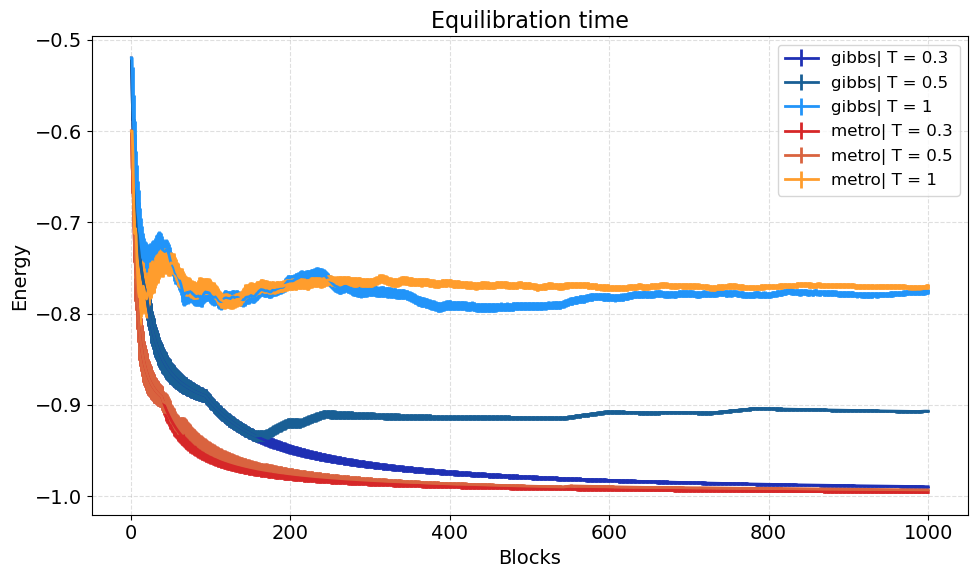

In [5]:

# Parameters
t_equilibs = ['0.3', '0.5', '1']
methods = ['gibbs', 'metro']
colors = ["#1f30b4", "#195f95", "#2194f9", '#d62728', "#d9633f", "#ff9d2d"]

plt.figure()
i=0
for method in methods:
    for T in t_equilibs:   
        data = np.loadtxt("NSL_SIMULATOR/equilib_" + method + "/OUTPUT_T=" + T + "/total_energy.dat")
        blocks = data[:, 0]
        energy_single = data[:, 1]
        energy_progressive = data[:, 2]
        error = data[:, 3]

        #plt.plot(blocks, energy_single, label='Single data ' + method)
        plt.errorbar(blocks, energy_progressive, error, label= method + '| T = ' + T, color = colors[i])
        i = i+1

# Formattazione
plt.title('Equilibration time')
plt.xlabel('Blocks')
plt.ylabel('Energy')
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()




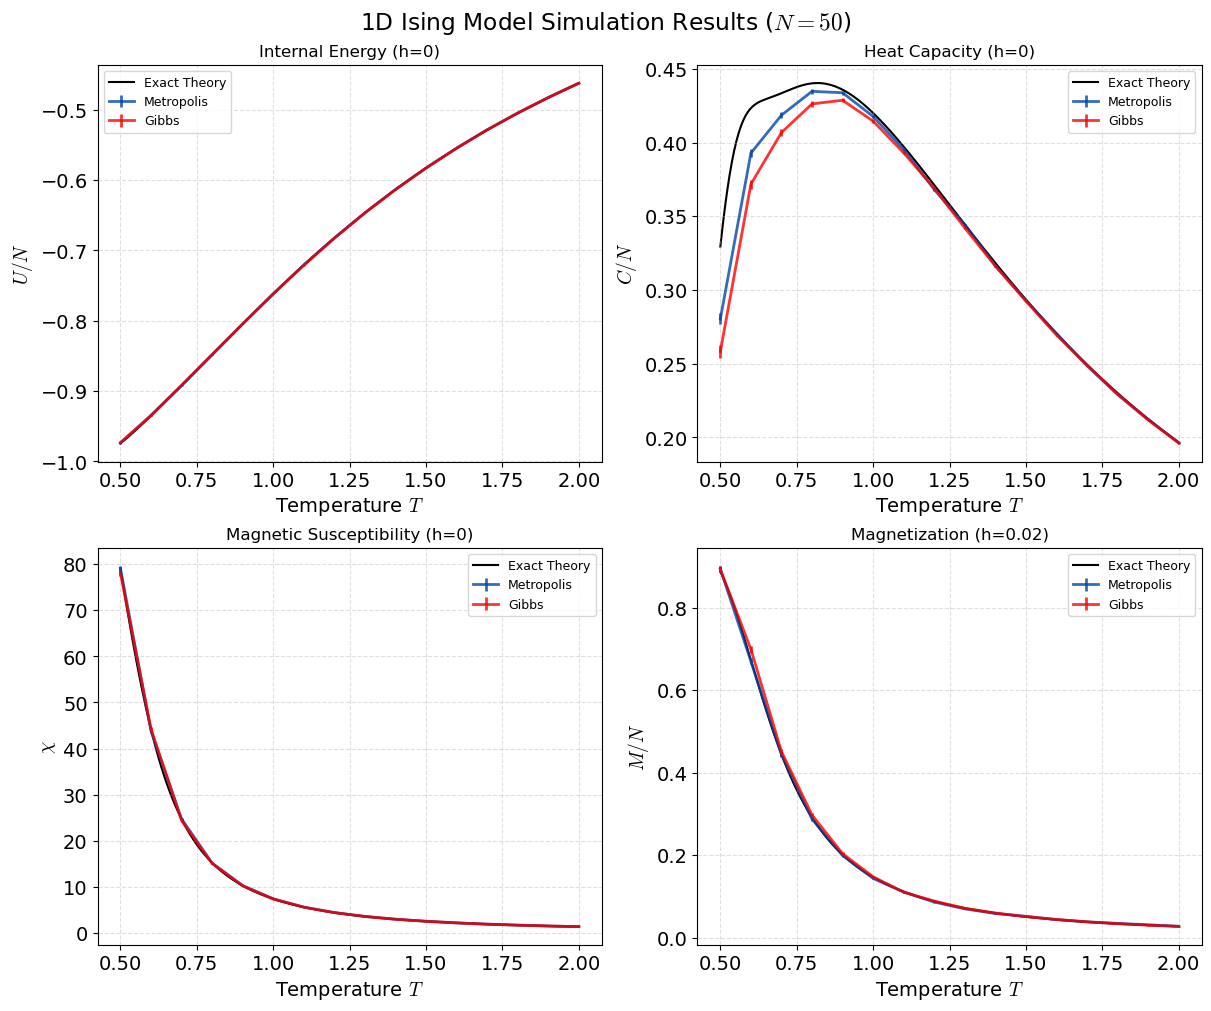

In [6]:
import subprocess 
import shutil 
import os 

# ==============================================================================
# Helper functions for I/O and Theoretical Curves
# ==============================================================================

def update_temp(new_temp):
    """Updates the temperature value in the input.dat file."""
    with open('NSL_SIMULATOR/INPUT/input.dat', 'r') as f:
        lines = f.readlines()
    lines[2] = f"TEMP                {new_temp}\n"
    with open('NSL_SIMULATOR/INPUT/input.dat', 'w') as f:
        f.writelines(lines)

# Exact 1D Ising Model parameters and functions
Ns = 50 
J = 1.0 

def exact_energy(temp):
    th = np.tanh(J/temp)
    thN = th**Ns
    ch = 1/th
    return -J * (th + ch*thN) / (1 + thN)

def exact_heat_capacity(temp):
    beta = 1/temp
    th = np.tanh(J/temp)
    thN = th**Ns
    ch = 1/th
    return ((beta*J)**2) * (((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN)) - Ns*((th+ch*thN)/(1+thN))**2)

def exact_magnetization(temp):
    h = 0.02 # External magnetic field
    b = 1/temp
    l1 = np.exp(b*J)*np.cosh(b*h) + np.sqrt(np.exp(2*b*J)*np.cosh(b*h)**2 - 2*np.sinh(2*b*J))
    l2 = np.exp(b*J)*np.cosh(b*h) - np.sqrt(np.exp(2*b*J)*np.cosh(b*h)**2 - 2*np.sinh(2*b*J))
    Z = l1**Ns + l2**Ns
    return (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)**2 - 2*np.sinh(2*b*J))) 
            + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)**2 - 2*np.sinh(2*b*J))))) / Z

def exact_susceptibility(temp):
    beta = 1/temp
    th = np.tanh(J/temp)
    thN = th**Ns
    return beta * np.exp(2*beta*J) * (1-thN) / (1+thN)

# ==============================================================================
# Simulation Parameters Setup
# ==============================================================================

T_sup = 2.0
T_inf = 0.5
T_step = 0.1
n_T_step = int(np.round((T_sup - T_inf) / T_step)) + 1 
# Note: Simulating from high to low T (simulated annealing) improves thermalization
temperatures = np.linspace(T_sup, T_inf, n_T_step)

n_properties = 4
paths = [
    "NSL_SIMULATOR/OUTPUT/total_energy.dat",
    "NSL_SIMULATOR/OUTPUT/specific_heat.dat",
    "NSL_SIMULATOR/OUTPUT/susceptibility.dat",
    "NSL_SIMULATOR/OUTPUT/magnetization.dat"
]

sim_types = [2, 3]  # 2 = Metropolis, 3 = Gibbs

# Data storage matrices
data_metro = np.zeros((n_T_step, n_properties))
err_metro = np.zeros((n_T_step, n_properties))
data_gibbs = np.zeros((n_T_step, n_properties))
err_gibbs = np.zeros((n_T_step, n_properties))

# ==============================================================================
# Automation Loop
# ==============================================================================

for sim_type in sim_types:

    temp_data = np.zeros((n_T_step, n_properties))
    temp_err = np.zeros((n_T_step, n_properties))

    # --- PART 1: H = 0.0 (Energy, Heat Capacity, Susceptibility) ---
    # Setup initial input.dat: SIM_TYPE, J=1.0, H=0.0, RESTART=0, T=2.0
    with open('NSL_SIMULATOR/INPUT/input.dat', 'r') as f:
        lines = f.readlines() 
    lines[0] = f"SIMULATION_TYPE     {sim_type}   {1.0}     {0.0}\n" 
    lines[1] = f"RESTART             {0}\n" 
    lines[2] = f"TEMP                {2.0}\n" 
    with open('NSL_SIMULATOR/INPUT/input.dat', 'w') as f:
        f.writelines(lines) 

    # Run the simulator from scratch (T=2.0)
    subprocess.run(["./simulator.exe"], cwd="./NSL_SIMULATOR/SOURCE")

    # Extract the final progressive average (last block) for h=0 properties
    for j in range(n_properties - 1): 
        data = np.loadtxt(paths[j])
        temp_data[0, j] = data[-1, 2]
        temp_err[0, j] = data[-1, 3]

    # Save configuration to restart properly
    shutil.copy("NSL_SIMULATOR/OUTPUT/CONFIG/config.spin", "./NSL_SIMULATOR/INPUT/CONFIG/config.spin")

    # Enable RESTART for the subsequent lower temperatures
    with open('NSL_SIMULATOR/INPUT/input.dat', 'r') as f:
        lines = f.readlines() 
    lines[1] = f"RESTART             {1}\n" 
    with open('NSL_SIMULATOR/INPUT/input.dat', 'w') as f:
        f.writelines(lines) 

    # Loop over remaining temperatures
    for i in range(1, n_T_step):
        T = temperatures[i]
        update_temp(T)

        subprocess.run(["./simulator.exe"], cwd="./NSL_SIMULATOR/SOURCE")
        
        for j in range(n_properties - 1): 
            data = np.loadtxt(paths[j])
            temp_data[i, j] = data[-1, 2]
            temp_err[i, j] = data[-1, 3]
    
        shutil.copy("NSL_SIMULATOR/OUTPUT/CONFIG/config.spin", "./NSL_SIMULATOR/INPUT/CONFIG/config.spin")


    # --- PART 2: H = 0.02 (Magnetization) ---
    # Restart the entire process but with external field H=0.02
    with open('NSL_SIMULATOR/INPUT/input.dat', 'r') as f:
        lines = f.readlines() 
    lines[0] = f"SIMULATION_TYPE     {sim_type}   {1.0}     {0.02}\n" 
    lines[1] = f"RESTART             {0}\n" 
    lines[2] = f"TEMP                {2.0}\n" 
    with open('NSL_SIMULATOR/INPUT/input.dat', 'w') as f:
        f.writelines(lines) 

    subprocess.run(["./simulator.exe"], cwd="./NSL_SIMULATOR/SOURCE")

    data = np.loadtxt(paths[3])
    temp_data[0, 3] = data[-1, 2]
    temp_err[0, 3] = data[-1, 3]

    shutil.copy("NSL_SIMULATOR/OUTPUT/CONFIG/config.spin", "./NSL_SIMULATOR/INPUT/CONFIG/config.spin")

    with open('NSL_SIMULATOR/INPUT/input.dat', 'r') as f:
        lines = f.readlines() 
    lines[1] = f"RESTART             {1}\n" 
    with open('NSL_SIMULATOR/INPUT/input.dat', 'w') as f:
        f.writelines(lines) 

    for i in range(1, n_T_step):
        T = temperatures[i]
        update_temp(T)

        subprocess.run(["./simulator.exe"], cwd="./NSL_SIMULATOR/SOURCE")
        
        data = np.loadtxt(paths[3])
        temp_data[i, 3] = data[-1, 2]
        temp_err[i, 3] = data[-1, 3]
    
        shutil.copy("NSL_SIMULATOR/OUTPUT/CONFIG/config.spin", "./NSL_SIMULATOR/INPUT/CONFIG/config.spin")
    
    # Store results based on simulation type
    if sim_type == 2:
        data_metro = temp_data
        err_metro = temp_err
    elif sim_type == 3:
        data_gibbs = temp_data
        err_gibbs = temp_err
    else:
        raise ValueError("Unknown simulation type encountered.")


# ==============================================================================
# Plotting the Results
# ==============================================================================

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), constrained_layout=True)
ax = ax.flatten()

titles = ['Internal Energy (h=0)', 'Heat Capacity (h=0)', 
          'Magnetic Susceptibility (h=0)', 'Magnetization (h=0.02)']

ylabels = [r'$U/N$', r'$C/N$', r'$\chi$', r'$M/N$']

c_theory = 'black'

for j in range(n_properties):
    # Scatter plots for simulations
    ax[j].errorbar(temperatures, data_metro[:, j], yerr=err_metro[:, j], 
                   label='Metropolis', alpha=0.8, markersize=5)
    ax[j].errorbar(temperatures, data_gibbs[:, j], yerr=err_gibbs[:, j], 
                   label='Gibbs', alpha=0.8, markersize=5)
    
    # Aesthetics
    ax[j].set_xlabel(r"Temperature $T$")
    ax[j].set_ylabel(ylabels[j])
    ax[j].set_title(titles[j], fontsize=12)

# Overlay exact theoretical curves
# Creating a smooth dense array for plotting analytical curves
smooth_T = np.linspace(0.5, 2.0, 200)

ax[0].plot(smooth_T, exact_energy(smooth_T), color=c_theory, linestyle='-', linewidth=1.5, label='Exact Theory', zorder=0)
ax[1].plot(smooth_T, exact_heat_capacity(smooth_T), color=c_theory, linestyle='-', linewidth=1.5, label='Exact Theory', zorder=0)
ax[2].plot(smooth_T, exact_susceptibility(smooth_T), color=c_theory, linestyle='-', linewidth=1.5, label='Exact Theory', zorder=0)
ax[3].plot(smooth_T, exact_magnetization(smooth_T), color=c_theory, linestyle='-', linewidth=1.5, label='Exact Theory', zorder=0)

for j in range(n_properties):
    ax[j].legend(loc='best', fontsize=9)

fig.suptitle(r"1D Ising Model Simulation Results ($N=50$)")
plt.show()

Here I implemented a python script that autonomously runs the simulations, varying temperature while doing it, and saves and plots data, both for Metropolis and for Gibbs. In the image I show the result of simulations (Metropolis and Gibbs) and the theoric value. The temperature varies from 2.0 to 0.5, with step of 0.1. 
Also, in the code I pass the last configuration of the system to the next one, so that the starting state is not too disordered, and the system equilibrates in short time.

Data shows good compatibility with theoric model. Also, for lower temperatures the simulation becomes less accurate. This is due to the fact that Metropolis algorithm accepts less and less moves with as temperature drops. The Gibbs algorithm accepts all moves, but probably the fact that most of them leave the system unvaried makes it less precise.